# Robotic insertion sort: initial scene

Create one Fetch arm and four colored cubes using the existing
`FetchPickAndPlaceConstruction` class. For this first step, the cubes occupy
four fixed slots in a row along the world **y** axis, with 9 cm between centers.
The row sits 10 cm beyond the initial gripper position along **x**.
All cubes rest on the table; the arm keeps its built-in initial pose.

This notebook initializes and renders the scene only. The `PickAndPlace` case
provides the scene; its reward is not an insertion-sort specification.
No sorting policy or ordering keys are assigned yet.

**Runtime:** uses the original `FetchPickAndPlaceConstruction`, Gym 0.21,
and `mujoco-py`. The project vendors Gym's original source with a packaging-only
correction so `uv sync` can install it. On Apple Silicon, the setup helper uses
a project-local MuJoCo 2.1.1 framework and Apple clang compatibility wrapper.
No system library installation is needed.

For a fresh Apple Silicon checkout, run once from `roboverify`:

```bash
unset LD_PRELOAD
uv sync
uv run python3 -m scripts.setup_mujoco_macos
```

Then select this project's `.venv` notebook kernel and run all cells.
An existing `MUJOCO_PY_MUJOCO_PATH` takes precedence on other installations.
The Apple Silicon setup is a compatibility workaround; see
[mujoco-py issue 682](https://github.com/openai/mujoco-py/issues/682).
It does not establish equivalence to simulations run under MuJoCo 2.1.0.


In [11]:
from pathlib import Path
import inspect
import os
import sys

# Must precede simulator imports (see the project's AGENTS.md).
os.environ.pop("LD_PRELOAD", None)

import numpy as np
import z3

PROJECT_ROOT = next(
    (root for parent in [Path.cwd(), *Path.cwd().parents]
     for root in (parent, parent / "roboverify")
     if (root / "synthesis/environment/cee_us_env/fpp_construction_env.py").is_file()),
    None,
)
if PROJECT_ROOT is None:
    raise RuntimeError("Run this notebook from the RoboVerify repository.")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [12]:
# Scene configuration. Positions below are offsets in meters.
NUM_BLOCKS = 4
SEED = 42
ROW_X_OFFSET = 0.10
SLOT_SPACING = 0.09
SLOT_Y_OFFSETS = (np.arange(NUM_BLOCKS) - (NUM_BLOCKS - 1) / 2) * SLOT_SPACING
IMAGE_WIDTH = 960
IMAGE_HEIGHT = 720
IMAGE_PATH = PROJECT_ROOT / "notebooks/robotic_insertion_sort_initial_state.png"

assert SLOT_SPACING > 0.05  # Cubes are 5 cm wide in the existing scene XML.
assert abs(ROW_X_OFFSET) <= 0.15
assert np.max(np.abs(SLOT_Y_OFFSETS)) <= 0.15

In [13]:
# Configure the project-local runtime before importing mujoco_py.
from synthesis.environment.cee_us_env.runtime import configure_local_mujoco

mujoco_path = configure_local_mujoco()
if not mujoco_path.is_dir():
    raise RuntimeError(
        f"MuJoCo runtime missing at {mujoco_path}. "
        "On Apple Silicon, run: uv run python3 -m scripts.setup_mujoco_macos"
    )

from synthesis.environment.cee_us_env.fpp_construction_env import FetchPickAndPlaceConstruction

print(f"MuJoCo runtime: {mujoco_path}")

MuJoCo runtime: /Users/luoninz1/Documents/RoboVerify/roboverify/.runtime/mujoco211


In [14]:
# Implement an environment with one robotic arm and 4 objects.
# For now, just instantiate the objects and the arm, and make sure they are in the right place.
# Output an image of the initial state of the environment.

# Close the previous simulator when rerunning this cell.
if "env" in globals():
    env.close()

# The existing class samples with NumPy's global RNG; its seed() is a no-op.
np.random.seed(SEED)
env = FetchPickAndPlaceConstruction(
    name="robotic_insertion_sort_initial_scene",
    sparse=False,
    shaped_reward=False,
    num_blocks=NUM_BLOCKS,
    reward_type="sparse",
    case="PickAndPlace",
    simple=True,
    visualize_target=False,
    visualize_mocap=False,
)

try:
    env.reset()  # Legacy API: returns observation only.
    block_positions = np.column_stack((
        np.full(NUM_BLOCKS, env.initial_gripper_xpos[0] + ROW_X_OFFSET),
        env.initial_gripper_xpos[1] + SLOT_Y_OFFSETS,
        np.full(NUM_BLOCKS, env.height_offset),
    ))

    # Set each free joint's position and identity quaternion, and clear velocity.
    for name, position in zip(env.object_names, block_positions):
        env.sim.data.set_joint_qpos(
            f"{name}:joint", np.concatenate((position, [1.0, 0.0, 0.0, 0.0]))
        )
        env.sim.data.set_joint_qvel(f"{name}:joint", np.zeros(6))
    env.sim.forward()

    # Keep unused pick-and-place goals consistent with this initial layout.
    env.goal = np.concatenate((block_positions.ravel(), np.zeros(3)))
    observation = env.flatten_observation(env._get_obs())
    initial_state = env.get_GT_state().copy()

    # Check actual simulator geometry, not just the requested coordinates.
    actual_positions = np.array([
        env.sim.data.get_site_xpos(name).copy() for name in env.object_names
    ])
    half_sizes = np.array([
        env.sim.model.geom_size[env.sim.model.geom_name2id(name)].copy()
        for name in env.object_names
    ])
    table_id = env.sim.model.geom_name2id("table0")
    table_height = env.sim.data.geom_xpos[table_id, 2]  # table0 is a plane.
    assert len(env.object_names) == NUM_BLOCKS
    assert np.isfinite(observation).all()
    np.testing.assert_allclose(actual_positions, block_positions, atol=1e-6)
    np.testing.assert_allclose(actual_positions[:, 2] - half_sizes[:, 2], table_height, atol=2e-3)
    for i in range(NUM_BLOCKS):
        for j in range(i):
            assert np.any(
                np.abs(actual_positions[i, :2] - actual_positions[j, :2])
                > half_sizes[i, :2] + half_sizes[j, :2]
            ), f"Blocks {i} and {j} overlap."
    grip_position = env.sim.data.get_site_xpos("robot0:grip").copy()
    assert grip_position[2] > np.max(actual_positions[:, 2] + half_sizes[:, 2])

    print("Initial block centers (world x, y, z; meters):")
    for name, position in zip(env.object_names, actual_positions):
        print(f"{name}: {np.round(position, 4)}")
except Exception:
    env.close()
    raise


def reset_initial_scene():
    """Restore the fixed row; env.reset() instead samples a new random layout."""
    env.set_GT_state(initial_state.copy())
    return env.flatten_observation(env._get_obs())

Initial block centers (world x, y, z; meters):
object0: [1.4444 0.6141 0.4246]
object1: [1.4444 0.7041 0.4246]
object2: [1.4444 0.7941 0.4246]
object3: [1.4444 0.8841 0.4246]


Creating offscreen glfw


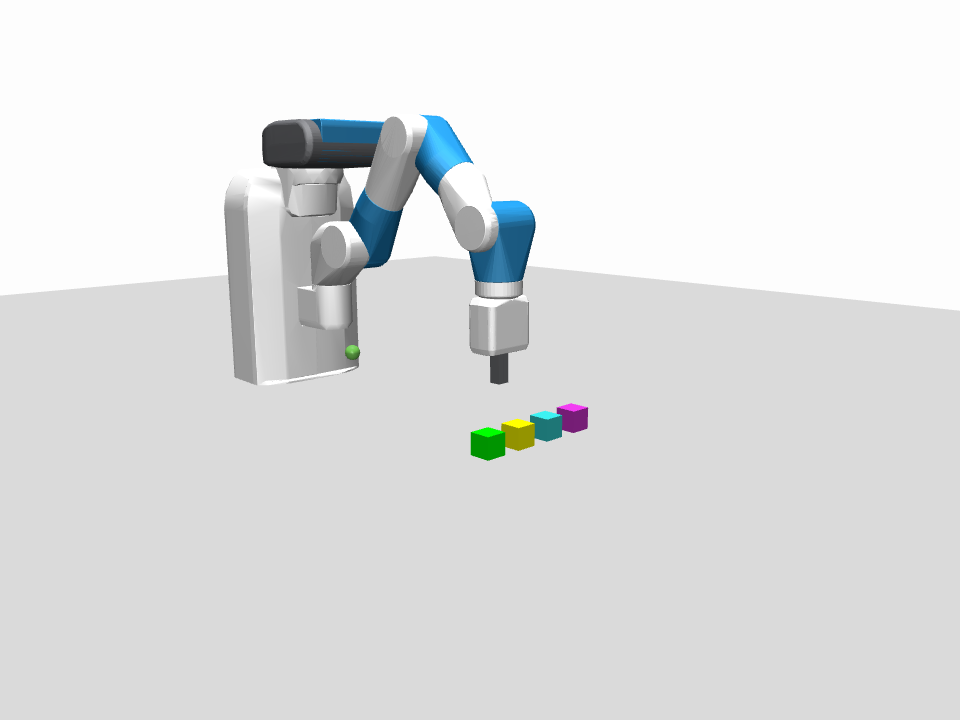

Saved initial state: /Users/luoninz1/Documents/RoboVerify/roboverify/notebooks/robotic_insertion_sort_initial_state.png


In [15]:
# Render the actual simulator state and display/save the same RGB image.
import imageio.v2 as imageio
from IPython.display import Image, display

try:
    initial_frame = env.render(mode="rgb_array", width=IMAGE_WIDTH, height=IMAGE_HEIGHT)
    assert initial_frame.shape == (IMAGE_HEIGHT, IMAGE_WIDTH, 3)
    assert initial_frame.dtype == np.uint8
    assert np.ptp(initial_frame) > 0, "Renderer returned a blank image."
    imageio.imwrite(IMAGE_PATH, initial_frame)
    display(Image(data=IMAGE_PATH.read_bytes()))
    print(f"Saved initial state: {IMAGE_PATH}")
except Exception:
    env.close()
    raise

The environment stays available as `env` for later notebook cells.
Call `reset_initial_scene()` to restore this exact scene; ordinary `env.reset()`
uses the class's random placement. Call `env.close()` when finished.
The class uses the legacy four-value `step()` API.

Local implementation references:
[environment class](../synthesis/environment/cee_us_env/fpp_construction_env.py),
[constructor and rendering](../synthesis/environment/cee_us_env/fpp_construction/construction.py),
[robot and block geometry](../synthesis/environment/cee_us_env/fpp_construction/xml_gen.py).